In [1]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv('C:\\Users\\ASUS\\Documents\\Kaggle\\Student_health_risk\\dataset\\train_featured.csv')

In [6]:
df.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,...,physical_activity_level,smoking_alcohol,gender,bmi_category,sleep_category,step_category,exercise_category,hydration_category,activity_score,sleep_activity_interaction
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,...,sedentary,yes,female,overweight,insufficient,low,low,adequate,26254.8,103.356
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,...,moderate,yes,other,overweight,insufficient,moderate,high,low,493560.9,275.947
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,...,active,yes,male,normal,insufficient,high,moderate,adequate,541629.6,201.549
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,...,active,occasional,female,normal,insufficient,moderate,high,adequate,429722.6,281.530
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,...,sedentary,NaN,male,overweight,recommended,moderate,high,adequate,302864.0,332.580


In [8]:
X = df.drop(
    columns="health_condition"
)

y = df[
    "health_condition"
]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
numerical_features = (
    X_train
    .select_dtypes(
        include=["number"]
    )
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(
        exclude=["number"]
    )
    .columns
    .tolist()
)

In [11]:
from sklearn.pipeline import Pipeline

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [12]:
# numerical preprocessing pipeline
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median" # fill missing values with median for numerical features
            )
        ),

        (
            "scaler",
            StandardScaler() # scale numerical features
        )
    ]
)

# categorical preprocessing pipeline
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent" # fill missing values with the most frequent value for categorical features
            )
        ),

        (
            "encoder", # encode categorical features using one-hot encoding
            OneHotEncoder(
                handle_unknown="ignore" # ignore unknown categories during encoding
            )
        )
    ]
)

# Combine numerical and categorical pipelines into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [14]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print(
    X_train_processed.shape
)

(552070, 43)


In [16]:
from sklearn.preprocessing import (
    LabelEncoder
)

label_encoder = LabelEncoder()

y_train_encoded = (
    label_encoder.fit_transform(
        y_train
    )
)

y_test_encoded = (
    label_encoder.transform(
        y_test
    )
)

print(
    label_encoder.classes_
)

['at-risk' 'fit' 'unhealthy']


In [17]:
model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(X_train_processed.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.20),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        len(label_encoder.classes_),
        activation="softmax"
    )

])

In [18]:
model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [19]:
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    verbose=1

)

In [21]:
print(y_train.dtype)
print(y_train[:5])

print(type(y_train.iloc[0]) if hasattr(y_train, "iloc") else type(y_train[0]))

object
313415    at-risk
3515      at-risk
501194    at-risk
303602    at-risk
117943    at-risk
Name: health_condition, dtype: object
<class 'str'>


In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

In [23]:
print(y_train_encoded[:10])

print(y_train_encoded.dtype)

[0 0 0 0 0 0 0 0 0 0]
int32


In [25]:
history = model.fit(
    X_train_processed,
    y_train_encoded,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/100
3451/3451 [==============================] - 47s 13ms/step - loss: 0.1712 - accuracy: 0.9508 - val_loss: 0.1309 - val_accuracy: 0.9628 - lr: 0.0010
Epoch 2/100
3451/3451 [==============================] - 30s 9ms/step - loss: 0.1372 - accuracy: 0.9616 - val_loss: 0.1268 - val_accuracy: 0.9630 - lr: 0.0010
Epoch 3/100
3451/3451 [==============================] - 27s 8ms/step - loss: 0.1325 - accuracy: 0.9622 - val_loss: 0.1252 - val_accuracy: 0.9628 - lr: 0.0010
Epoch 4/100
3451/3451 [==============================] - 41s 12ms/step - loss: 0.1302 - accuracy: 0.9623 - val_loss: 0.1243 - val_accuracy: 0.9630 - lr: 0.0010
Epoch 5/100
3451/3451 [==============================] - 35s 10ms/step - loss: 0.1285 - accuracy: 0.9627 - val_loss: 0.1241 - val_accuracy: 0.9632 - lr: 0.0010
Epoch 6/100
3451/3451 [==============================] - 32s 9ms/step - loss: 0.1272 - accuracy: 0.9629 - val_loss: 0.1220 - val_accuracy: 0.9633 - lr: 0.0010
Epoch 7/100
3451/3451 [====================

In [26]:
train_probs = model.predict(X_train_processed)

test_probs = model.predict(X_test_processed)

train_pred = train_probs.argmax(axis=1)

test_pred = test_probs.argmax(axis=1)


4314/4314 [==============================] - 7s 2ms/step


In [27]:
train_accuracy = accuracy_score(
    y_train_encoded,
    train_pred
)

test_accuracy = accuracy_score(
    y_test_encoded,
    test_pred
)

train_macro_f1 = f1_score(
    y_train_encoded,
    train_pred,
    average="macro"
)

test_macro_f1 = f1_score(
    y_test_encoded,
    test_pred,
    average="macro"
)

balanced_acc = balanced_accuracy_score(
    y_test_encoded,
    test_pred
)

print(f"Training Accuracy : {train_accuracy:.4f}")

print(f"Testing Accuracy : {test_accuracy:.4f}")

print(f"Balanced Accuracy : {balanced_acc:.4f}")

print(f"Training Macro F1 : {train_macro_f1:.4f}")

print(f"Testing Macro F1 : {test_macro_f1:.4f}")

Training Accuracy : 0.9654
Testing Accuracy : 0.9654
Balanced Accuracy : 0.8582
Training Macro F1 : 0.9035
Testing Macro F1 : 0.9034


In [28]:
print(

    classification_report(

        y_test_encoded,

        test_pred,

        target_names=label_encoder.classes_

    )

)

              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.96      0.78      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018



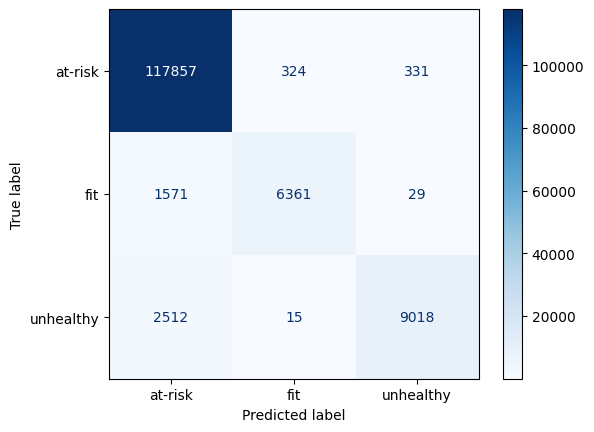

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_test_encoded,

    test_pred,

    display_labels=label_encoder.classes_,

    cmap="Blues"

)

plt.show()

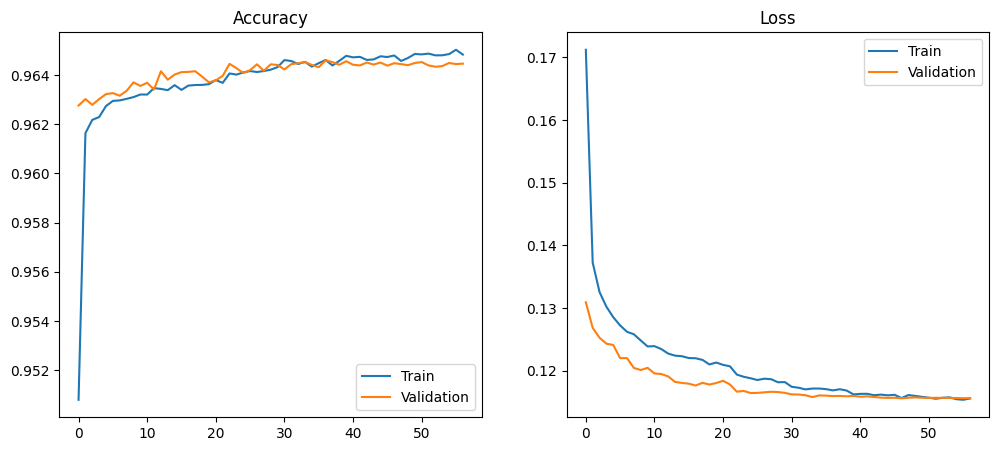

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.title("Loss")

plt.legend()

plt.show()